# TTADDA-UAV potato dataset — hands-on Colab demo (CPU)

Reproduces the **minimal reproduction path** of *TTADDA-UAV: A multi-season RGB and multispectral UAV dataset of potato fields collected in Japan and the Netherlands* (van Marrewijk et al., **Data in Brief** 62:112004, 2025, [doi:10.1016/j.dib.2025.112004](https://doi.org/10.1016/j.dib.2025.112004)).

**What this notebook does** (CPU only, no model weights involved):
1. Downloads the authors' **MIAPPE metadata spreadsheet** from the pinned public 4TU.ResearchData record.
2. Performs a **ranged partial download** of the 12.6 GB `TTADDA_NARO_2021.zip` — only the ZIP central directory and a few small members (ground-truth CSVs, README, one small orthomosaic) are transferred.
3. Runs the **authors' verbatim loader** (`scripts/data_loader.py`, pinned commit `2fd6e1902e618619a7d236c9007b9e4b9cd6aac7`) to explore observation units, variables, sensors, ground coverage and yield of the TTADDA_NARO_2021 trial, and lists RGB orthomosaic imagery links.

**Provenance**: paper DOI 10.1016/j.dib.2025.112004 · code https://github.com/NPEC-NL/MIAPPE_TTADDA_dataset @ `2fd6e1902e618619a7d236c9007b9e4b9cd6aac7` (Apache-2.0) · data 4TU item `f2307c47-9a1a-474a-a0d9-e09ee1b7512c` (CC BY). All downloads happen inside this Colab VM under `/content`; no host files are used.

**日本語説明**: このノートブックは TTADDA-UAV（ジャガイモ圃場のUAV RGB/マルチスペクトルデータセット、Data in Brief 2025）のデータ論文を、著者公開コードと4TU公開レコードのみで動かす CPU 向けデモです。12.6 GB のZIPを丸ごと落とさず、HTTP Range 要求で ZIP 中央ディレクトリだけを読み、必要な小さいファイル（CSV・README・小さいオルソモザイク1枚）だけを転送します。重い機械学習やモデル重みは不要です。

In [ ]:
!pip install -q omegaconf pandas geopandas openpyxl natsort matplotlib requests tqdm rasterio

## 1 · Paths and pinned record

Everything under `/content/data/TTADDA_UAV_01` — the same layout the authors' `config.yaml` expects (`project_dir: data/TTADDA_UAV_01`).

**日本語**: 作業ディレクトリは著者の `config.yaml` と同じ `data/TTADDA_UAV_01` 構成に揃えます。

In [ ]:
from pathlib import Path
import requests

PROJECT_DIR = Path("/content/data/TTADDA_UAV_01")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# Pinned public file URLs from 4TU item f2307c47-9a1a-474a-a0d9-e09ee1b7512c (v1, published 2025-09-03)
XLSX_URL = "https://data.4tu.nl/file/f2307c47-9a1a-474a-a0d9-e09ee1b7512c/b17bb6c0-0493-4f0d-9729-334e2baa9c1d"
ZIP_URL = "https://data.4tu.nl/file/f2307c47-9a1a-474a-a0d9-e09ee1b7512c/851a2fcf-0a5f-4e5e-90fa-4fa1fbf99806"
README_URL = "https://data.4tu.nl/file/f2307c47-9a1a-474a-a0d9-e09ee1b7512c/13fe672b-9fa8-4847-ba5d-45b835cdda5d"
XLSX_SIZE = 2328999
ZIP_SIZE = 12625567724

def head_check(url):
    r = requests.head(url, allow_redirects=True, timeout=60)
    print(url.split("/")[-1], "->", r.status_code, r.headers.get("Content-Length"), r.headers.get("Content-Type"))

for u in (XLSX_URL, ZIP_URL, README_URL):
    head_check(u)

b17bb6c0-0493-4f0d-9729-334e2baa9c1d -> 200 2328999 application/octet-stream


851a2fcf-0a5f-4e5e-90fa-4fa1fbf99806 -> 200 12625567724 application/octet-stream


13fe672b-9fa8-4847-ba5d-45b835cdda5d -> 200 3694 application/octet-stream


## 2 · Download the MIAPPE metadata spreadsheet (2.3 MB)

The authors' `main.py` expects `MIAPPE_Minimal_Spreadsheet_Template_TTADDAv4.xlsx` in the project folder. It is a standalone public file in the 4TU item.

**日本語**: 著者コードが読み込む MIAPPE メタデータ表（Excel）を、サイズ確認付きでダウンロードします。

In [ ]:
import hashlib

xlsx_path = PROJECT_DIR / "MIAPPE_Minimal_Spreadsheet_Template_TTADDAv4.xlsx"
if not xlsx_path.exists():
    with requests.get(XLSX_URL, timeout=300, stream=True) as r:
        r.raise_for_status()
        data = r.content
    assert len(data) == XLSX_SIZE, f"size mismatch: {len(data)} != {XLSX_SIZE}"
    xlsx_path.write_bytes(data)
    print("sha256:", hashlib.sha256(data).hexdigest())
print("xlsx present:", xlsx_path, xlsx_path.stat().st_size, "bytes")

import openpyxl
wb = openpyxl.load_workbook(xlsx_path, read_only=True)
print("sheets:", wb.sheetnames)
wb.close()

sha256: 0842fb11e7afa79b667d39703d9acfa71e61beed41d56f1172197f17aa0392ac
xlsx present: /content/data/TTADDA_UAV_01/MIAPPE_Minimal_Spreadsheet_Template_TTADDAv4.xlsx 2328999 bytes


sheets: ['README', 'Investigation', 'Study', 'Person', 'Data file', 'Biological Material', 'Observation Unit', 'Sensor', 'Observed Variable', 'Events']


## 3 · Read the study README (3.7 KB, from the same 4TU item)

**日本語**: データセット同梱のREADMEも取得して中身を確認します。

In [ ]:
r = requests.get(README_URL, timeout=120)
r.raise_for_status()
assert len(r.content) == 3694, f"unexpected README size {len(r.content)}"
readme_path = PROJECT_DIR / "README_TTADDA_NARO_2021.txt"
readme_path.write_bytes(r.content)
print(r.text)

This readme belongs to the TTADDA_NARO_2021: A subset of the multi-season RGB and multispectral TTADDA-UAV potato dataset.

Title: TTADDA_NARO_2021: A subset of the multi-season RGB and multispectral TTADDA-UAV potato dataset.

Related publication: TTADDA-UAV: A Multi-Season RGB and Multispectral UAV Dataset of Potato Fields Collected in Japan and the Netherlands
DOI: https://doi.org/10.1016/j.dib.2025.112004 
Authors: Bart. M. van Marrewijk, Stephen Njehia Njane, Shogo Tsuda, Marcel van Culemborg, Gerrit Polder, Kenji Katayama, Tim van Daalen, Rick van de Zedde

Corresponding author: Bart M. van Marrewijk & Stephen Njehia Njane
Contact Information: bart.vanmarrewijk@wur.nl;njane.stephen.njehia344@naro.go.jp

################################# Background information ##########################

The TTADDA_NARO_2021 dataset includes drone imagery, manual measurements, and on-site weather data. Weekly RGB and multispectral images were processed with Agisoft Metashape to create a DEM, RGB a

## 4 · Ranged partial download of the 12.6 GB ZIP

We never download the full archive. `HTTPRangeFile` emulates a seekable file over HTTP `Range` requests; `zipfile` reads the **central directory** (near the end of the file) through it, and we then extract only selected small members. If the server rejects range requests, a documented fallback streams the full ZIP to `/content` instead (slow but bounded).

**日本語**: 12.6 GB のZIPを全体ダウンロードしません。HTTP Range 要求をシーク可能なファイルのように見せ、ZIPの中央ディレクトリだけを読んで一覧を作り、必要な小ファイルのみ抽出します（Range非対応の場合は全文ダウンロードにフォールバック）。

In [ ]:
import io
import zipfile

class HTTPRangeFile(io.RawIOBase):
    """Seekable read-only file over HTTP Range requests (for remote ZIP access)."""
    def __init__(self, url, block=1 << 20):
        self.url, self.block = url, block
        self.pos = 0
        self._buf = b""
        self._buf_start = 0
        probe = requests.get(url, headers={"Range": "bytes=0-0"}, timeout=60)
        if probe.status_code == 206 and "Content-Range" in probe.headers:
            self.length = int(probe.headers["Content-Range"].rsplit("/", 1)[1])
        elif probe.status_code == 200:
            raise IOError("Server does not support HTTP Range; use the full-download fallback.")
        else:
            raise IOError(f"Unexpected status {probe.status_code}")
        probe.close()

    def readable(self): return True
    def seekable(self): return True

    def _fetch(self, start, end):  # inclusive end
        import time
        last = None
        for attempt in range(6):
            try:
                r = requests.get(self.url, headers={"Range": f"bytes={start}-{end}"}, timeout=180)
                if r.status_code == 206:
                    return r.content
                r.raise_for_status()  # 200 without Range support -> retry/raise
            except requests.RequestException as e:
                last = e
            time.sleep(min(60, 5 * (2 ** attempt)))  # backoff for 4TU transient 5xx
        raise IOError(f"ranged fetch failed after retries: {last}")

    def read(self, size=-1):
        if size is None or size < 0:
            size = self.length - self.pos
        size = min(size, self.length - self.pos)
        if size <= 0: return b""
        if not (self._buf_start <= self.pos < self._buf_start + len(self._buf)):
            want = max(size, self.block)
            end = min(self.pos + want, self.length) - 1
            self._buf = self._fetch(self.pos, end)
            self._buf_start = self.pos
        off = self.pos - self._buf_start
        out = self._buf[off:off + size]
        self.pos += len(out)
        return out

    def seek(self, offset, whence=0):
        if whence == 0: self.pos = offset
        elif whence == 1: self.pos += offset
        elif whence == 2: self.pos = self.length + offset
        return self.pos

    def tell(self): return self.pos

remote_zip = HTTPRangeFile(ZIP_URL)
print("remote zip size:", remote_zip.length, "bytes (expect", ZIP_SIZE, ")")
zf = zipfile.ZipFile(remote_zip)
infos = zf.infolist()
print("members:", len(infos))
total = sum(i.file_size for i in infos)
print(f"uncompressed total: {total/1e9:.2f} GB")

remote zip size: 12625567724 bytes (expect 12625567724 )


members: 168
uncompressed total: 12.66 GB


## 5 · Select small members and extract them

We take: the study CSVs (ground truth), shapefile sidecar sets, text files, and — only if small enough — the **smallest** RGB orthomosaic for a visual check. Everything stays under `/content`.

**日本語**: CSV（収量・被覆率など地面データ）、シェープファイル一式、テキスト、そして十分小さければ最小のRGBオルソモザイク1枚だけを抽出します。

In [ ]:
EXTS_KEEP = {".csv", ".txt", ".md", ".json"}
SHP_EXTS = {".shp", ".dbf", ".shx", ".prj", ".cpg"}
MAX_MEMBER = 300 << 20          # never extract a member larger than 300 MB
EXTRACT_BUDGET = 600 << 20      # total extraction budget

rgb_tiffs = [i for i in infos if i.filename.lower().endswith(".tif") and "rgb" in i.filename.lower()]
ortho_pick = min(rgb_tiffs, key=lambda i: i.file_size) if rgb_tiffs else None
print(f"{len(rgb_tiffs)} rgb orthomosaic members; smallest:", ortho_pick and (ortho_pick.filename, f"{ortho_pick.file_size/1e6:.1f} MB"))

to_extract = []
for i in infos:
    if i.is_dir() or i.file_size > MAX_MEMBER: continue
    ext = Path(i.filename).suffix.lower()
    if ext in EXTS_KEEP or ext in SHP_EXTS or i is ortho_pick:
        to_extract.append(i)
budget = 0
selected = []
for i in sorted(to_extract, key=lambda i: i.file_size):
    if budget + i.file_size > EXTRACT_BUDGET: continue
    selected.append(i); budget += i.file_size
print(f"selected {len(selected)} members, {budget/1e6:.1f} MB total")
for i in selected[:40]:
    print(f"  {i.file_size:>12,}  {i.filename}")

19 rgb orthomosaic members; smallest: ('TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-05-18/20210518_rgb.tif', '46.2 MB')
selected 11 members, 46.4 MB total
             5  TTADDA_NARO_2021/TTADDA_NARO_2021_F1/metadata/plot_shapefile.cpg
           292  TTADDA_NARO_2021/TTADDA_NARO_2021_F1/metadata/plot_shapefile.shx
           402  TTADDA_NARO_2021/TTADDA_NARO_2021_F1/metadata/plot_shapefile.prj
         1,899  TTADDA_NARO_2021/TTADDA_NARO_2021_F1/measurements/NARO_field_2021_GT_growthphases.csv
         2,807  TTADDA_NARO_2021/TTADDA_NARO_2021_F1/measurements/NARO_field_2021_GT_yield.csv
         5,380  TTADDA_NARO_2021/TTADDA_NARO_2021_F1/metadata/plot_shapefile.shp
         6,730  TTADDA_NARO_2021/TTADDA_NARO_2021_F1/metadata/plot_shapefile.dbf
        32,151  TTADDA_NARO_2021/TTADDA_NARO_2021_F1/measurements/NARO_field_2021_GT_additional.csv
        36,599  TTADDA_NARO_2021/TTADDA_NARO_2021_F1/measurements/NARO_field_2021_weather.csv
        42,430  TTADDA_NARO_2021/TTADDA_

**日本語**: 選択したメンバーを `/content/data/TTADDA_UAV_01/` 配下に展開します。サーバーがRange要求を拒否した場合の全文ダウンロードフォールバックもコメントで示します。

In [ ]:
import shutil

for i in selected:
    target = PROJECT_DIR / i.filename
    target.parent.mkdir(parents=True, exist_ok=True)
    if target.exists() and target.stat().st_size == i.file_size:
        continue
    with zf.open(i) as src, open(target, "wb") as dst:
        shutil.copyfileobj(src, dst, 1 << 20)
    assert target.stat().st_size == i.file_size, f"size mismatch {target}"
print("extraction done")

# Documented fallback if the server had rejected Range requests:
#   with requests.get(ZIP_URL, stream=True, timeout=7200) as r:  # ~12.6 GB stream to /content
#       ... write to file, then zipfile.ZipFile(local_path)

extraction done


## 6 · Reconcile the xlsx `dataFileLink` paths with extracted files

`data_loader.loadMIAPPE` resolves `data_folder / dataFileLink` from the **Data file** sheet. Zip-internal layouts can differ from the authors' external drive layout, so we map any missing link to the extracted file with the same basename (symlink).

**日本語**: Excelの`Data file`シートが指す相対パスと、ZIP内部の配置がずれていても、ベース名で対応付けてシンボリックリンクを張ることで著者コードをそのまま使えるようにします。

In [ ]:
import pandas as pd

df_datafile = pd.read_excel(xlsx_path, sheet_name="Data file")
print("Data file rows:", len(df_datafile), "| columns:", list(df_datafile.columns)[:12])

links = df_datafile["dataFileLink"].dropna().astype(str).tolist()
missing = []
for link in links:
    p = PROJECT_DIR / link
    if not p.exists():
        stem = Path(link).name
        hits = list(PROJECT_DIR.rglob(stem))
        if hits:
            p.parent.mkdir(parents=True, exist_ok=True)
            p.symlink_to(hits[0])
        else:
            missing.append(link)
n_naro = sum("NARO_2021" in l for l in links)
print(f"links total {len(links)}, NARO_2021 {n_naro}, unresolved now: {len(missing)}")
for m in missing[:10]: print("  unresolved:", m)

Data file rows: 507 | columns: ['studyId', 'obsUnitId', 'dataId', 'dataFileLink', 'dataFileDesc', 'dataFileVersion']


links total 507, NARO_2021 139, unresolved now: 496
  unresolved: TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-05-18/20210518-15m_transparent_reflectance_blue.tif
  unresolved: TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-05-18/20210518-15m_transparent_reflectance_green.tif
  unresolved: TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-05-18/20210518-15m_transparent_reflectance_nir.tif
  unresolved: TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-05-18/20210518-15m_transparent_reflectance_red edge.tif
  unresolved: TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-05-18/20210518-15m_transparent_reflectance_red.tif
  unresolved: TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-05-18/20210518_dsm.tif
  unresolved: TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-05-25/20210525-15m_transparent_reflectance_blue.tif
  unresolved: TTADDA_UAV_01/TTADDA_NARO_202

## 7 · Run the authors' verbatim loader

`scripts/data_loader.py` at commit `2fd6e1902e618619a7d236c9007b9e4b9cd6aac7` is written verbatim to `scripts/data_loader.py` and imported — no reimplementation. (Apache-2.0; © Bart van Marrewijk / WUR.)

**日本語**: 著者の `data_loader.py` を一字も変えずに書き出して import します。

In [ ]:
from pathlib import Path
LOADER_DIR = Path("scripts"); LOADER_DIR.mkdir(exist_ok=True)
(LOADER_DIR / "data_loader.py").write_text('import pandas as pd\nfrom pathlib import Path\nimport geopandas as gpd\nimport natsort\n\n\nclass loadMIAPPE():\n\n    def __init__(self, excel_path=Path("MIAPPE_Minimal_Spreadsheet_Template_TTADDAv4.xlsx"), data_folder=Path("/media/agro/PhDBart2/")):\n        self.excel_path = excel_path\n        self.data_folder = data_folder\n\n        self.excel_file = pd.read_excel(excel_path, sheet_name=None)\n\n    def get_data_id(self, temp_dataId, temp_variableId, obsUnitId=None, vis=False):\n        # Get the file name for the given dataId\n        file_name = self.data_folder / self.excel_file["Data file"][self.excel_file["Data file"]["dataId"] == temp_dataId]["dataFileLink"].values[0]\n        # Ensure temp_variableId is a list\n        if isinstance(temp_variableId, list):\n            columns = ["collectionDate", "obsUnitId"] + temp_variableId\n        else:\n            columns = ["collectionDate", "obsUnitId", temp_variableId]\n\n\n        if file_name.name.endswith(\'.csv\'):\n            # Read the CSV and select the columns\n            df_temp = pd.read_csv(file_name)[columns]\n            if obsUnitId is not None:\n                df_temp = df_temp[df_temp["obsUnitId"]==obsUnitId]\n            if vis:\n                plot_variable(df_temp, temp_variableId)\n        elif file_name.name.endswith(\'.shp\'):\n            if file_name.name.endswith(\'.shp\'):\n                gdf = gpd.read_file(file_name)\n                if vis:\n                    gdf.plot()\n                return gdf\n        elif file_name.name.endswith(\'.tif\'):\n            collectionDate = file_name.parent.stem\n            return [collectionDate, file_name]\n        else:\n            raise ValueError(f"Unsupported file type: {file_name}")\n\n        return df_temp\n\n    def get_observed_variables(self, temp_obsUnitId, temp_variableId, vis=False):\n        if isinstance(temp_variableId, list):\n            rows = self.excel_file["Observed Variable"][\n                (self.excel_file["Observed Variable"]["obsUnitId"] == temp_obsUnitId) &\n                (self.excel_file["Observed Variable"]["variableId"].isin(temp_variableId))\n            ]\n        else:\n            rows = self.excel_file["Observed Variable"][\n                (self.excel_file["Observed Variable"]["obsUnitId"] == temp_obsUnitId) &\n                (self.excel_file["Observed Variable"]["variableId"] == temp_variableId)\n            ]\n\n        result = []\n        for row in rows.itertuples(index=False):\n            df_temp = self.get_data_id(temp_dataId=row.dataId, temp_variableId=row.variableId, obsUnitId=temp_obsUnitId, vis=vis)\n            result.append(df_temp)\n        return result\n\n\n\n    def get_observation_unit_info(self, temp_studyId=None, temp_obsUnitId=None, verbose=True):\n        if temp_studyId is not None:\n            df_temp = self.excel_file["Observation Unit"][\n                (self.excel_file["Observation Unit"]["studyId"] == temp_studyId)]\n        elif temp_obsUnitId is not None:\n            df_temp = self.excel_file["Observation Unit"][\n                (self.excel_file["Observation Unit"]["obsUnitId"] == temp_obsUnitId)]\n        else:\n            raise ValueError("Either temp_studyId or temp_obsUnitId must be provided.")\n\n        ## if df_temp is empty\n        if df_temp.empty:\n            print("No data is available for the given study or observation unit.")\n        if verbose:\n            print("Rows:")\n            print(df_temp.to_string(index=False))\n\n        return df_temp\n\n    def get_sensor_info(self, sensorId=None):\n        if sensorId is None:\n            return self.excel_file["Sensor"]\n        else:\n            return self.excel_file["Sensor"][self.excel_file["Sensor"]["sensorId"]==sensorId]\n\n\ndef plot_variable(df_temp, x_axis="collectionDate", y_axis=None):\n    import matplotlib.pyplot as plt\n    plt.figure(figsize=(10, 5))\n    plt.plot(df_temp[x_axis], df_temp[y_axis], marker=\'o\')\n    plt.grid()\n    plt.xlabel("Collection Date")\n    plt.ylabel(y_axis)\n    plt.title(f"{y_axis} over {x_axis}")\n    plt.xticks(rotation=45)\n    plt.show()\n')

import sys; sys.path.insert(0, ".")
from scripts.data_loader import loadMIAPPE, plot_variable

obj = loadMIAPPE(
    excel_path=xlsx_path,
    data_folder=PROJECT_DIR,
)
print("sheets:", list(obj.excel_file.keys()))

sheets: ['README', 'Investigation', 'Study', 'Person', 'Data file', 'Biological Material', 'Observation Unit', 'Sensor', 'Observed Variable', 'Events']


## 8 · Explore TTADDA_NARO_2021: observation units and variables

**日本語**: NARO 2021 試験の観測ユニット（プロット）と測定変数一覧を著者コードで表示します。

In [ ]:
STUDY = "TTADDA_NARO_2021"
obs_units = obj.get_observation_unit_info(temp_studyId=STUDY)
print("n observation units:", len(obs_units))
print("example units:", obs_units["obsUnitId"].head(8).tolist() if "obsUnitId" in obs_units else obs_units.columns)

Rows:


         studyId biologicalMaterialId              obsUnitId                                                                                 obsUnitDesc obsUnitType  externalId  spatialDistribution obsUnitFactorValue
TTADDA_NARO_2021                  NaN    TTADDA_NARO_2021_F1                                                                         Field with 24 plots       field         NaN                  NaN                NaN
TTADDA_NARO_2021        Irish Cobbler  TTADDA_NARO_2021_F1P1 Plot with size 0.75x3[m], 1 ridge, approximiately 10 plants, plant density = 4.44 plants/m2        plot         NaN                  NaN                NaN
TTADDA_NARO_2021            Toyoshiro  TTADDA_NARO_2021_F1P2 Plot with size 0.75x3[m], 1 ridge, approximiately 10 plants, plant density = 4.44 plants/m2        plot         NaN                  NaN                NaN
TTADDA_NARO_2021              Madison  TTADDA_NARO_2021_F1P3 Plot with size 0.75x3[m], 1 ridge, approximiately 10 plants, plant dens

**日本語**: この試験で測定されている変数（variableId）の一覧を出します。

In [ ]:
vars_study = obj.excel_file["Observed Variable"]["variableId"][
    obj.excel_file["Observed Variable"]["studyId"] == STUDY].unique()
print("variables in", STUDY, ":", list(vars_study))

variables in TTADDA_NARO_2021 : ['air_temp_avg', 'air_temp_max', 'air_temp_min', 'air_rh_avg', 'percipitation_mm', 'rad_MJm2', 'soil_temp_depth5cm', 'soil_temp_depth10cm', 'soil_temp_depth30cm', 'soil_temp_depth50cm', 'soil_watercontent_depth 5cm', 'soil_watercontent_depth 10cm', 'soil_watercontent_depth 30cm', 'soil_watercontent_depth 50cm', 'air_vp_avg', 'plant_density_plantsm-2', 'tubwght_total_kgm-2', 'tubcnt_total_m-2', 'starch_content_%', 'stem_number_m-2', 'rgb_orthomosaic_camera1', 'dsm_orthomosaic_camera1', 'blue_orthomosaic_camera1', 'green_orthomosaic_camera1', 'red_orthomosaic_camera1', 'nir_orthomosaic_camera1', 'plot_location', 'sprouting', 'flower_budding', 'yellowing', 'senescence', 'NVDI', 'SPAD', 'plot_maxheight_cm', 'plot_maxwidth_cm']


**日本語**: センサー情報の一覧と、特定センサー（AmeDAS_T1）のレコードを表示します。

In [ ]:
print(obj.get_sensor_info())
print(obj.get_sensor_info(sensorId="AmeDAS_T1"))

                   sensorId        sensorType  \
0                 AmeDAS_T1       temperature   
1                AmeDAS_RH1  relativehumidity   
2                AmeDAS_mm1     percipitation   
3               AmeDAS_RAD1        irradiance   
4                   soil_T1       temperature   
5                  soil_WC1      watercontent   
6                 online_T1       temperature   
7               online_RAD1        irradiance   
8                online_RH1  relativehumidity   
9                online_VP1    vapourpressure   
10               RGB_drone1             drone   
11               RGB_drone2             drone   
12     blue_spectral_drone1             drone   
13    green_spectral_drone1             drone   
14      red_spectral_drone1             drone   
15  rededge_spectral_drone1             drone   
16      nir_spectral_drone1             drone   
17             ndvi_manual1              NDVI   
18             spad_manual1              SPAD   
19      plantheight_

## 9 · Ground truth: ground coverage and yield from CSVs

Pick a plot that has `ground_coverage` in this study, load its CSV through the authors' loader and plot the season curve; also show a yield record. (Variable availability follows the MIAPPE sheet; if a chosen variable is absent in NARO_2021 the cell reports it rather than failing.)

**日本語**: `ground_coverage`（被覆率）の季節変化を著者コードで描画し、収量レコードも表示します。変数がこの試験に無い場合はエラーではなく報告に留めます。

In [ ]:
import pandas as pd

ov = obj.excel_file["Observed Variable"]
want = "ground_coverage"
candidates = sorted(set(ov.loc[(ov["studyId"] == STUDY) & (ov["variableId"] == want), "obsUnitId"]))
print(want, "units in", STUDY, ":", len(candidates), candidates[:5])
if candidates:
    df_cov = obj.get_observed_variables(candidates[0], want)[0]
    print(df_cov.head())
    plot_variable(df_cov, y_axis=want)
else:
    print(f"No {want} variable rows for {STUDY} — check the variable list above.")

ground_coverage units in TTADDA_NARO_2021 : 0 []
No ground_coverage variable rows for TTADDA_NARO_2021 — check the variable list above.


**日本語**: 収量（yield）変数の有無を確認し、あれば最初の1つを読み出します。

In [ ]:
yield_vars = [v for v in vars_study if "tubwght" in v or "yield" in v.lower()]
print("yield-like variables:", yield_vars)
for v in yield_vars[:1]:
    units = sorted(set(ov.loc[(ov["studyId"] == STUDY) & (ov["variableId"] == v), "obsUnitId"]))
    if units:
        df_y = obj.get_observed_variables(units[0], v)[0]
        print(v, "for", units[0])
        print(df_y.head())

yield-like variables: ['tubwght_total_kgm-2']


tubwght_total_kgm-2 for TTADDA_NARO_2021_F1P1
  collectionDate              obsUnitId  tubwght_total_kgm-2
0     11-10-2021  TTADDA_NARO_2021_F1P1             4.223939


**日本語**: 併せて、圃場設置の気象観測（AmeDAS）の日次気温などを著者ローダで読み出して描画します（NARO 2021 に被覆率は無く、気象が主な地面データです）。

  collectionDate            obsUnitId  air_temp_avg
0     2021-01-01  TTADDA_NARO_2021_F1        -10.92
1     2021-01-02  TTADDA_NARO_2021_F1        -12.79
2     2021-01-03  TTADDA_NARO_2021_F1        -13.28
3     2021-01-04  TTADDA_NARO_2021_F1        -10.04
4     2021-01-05  TTADDA_NARO_2021_F1        -11.37


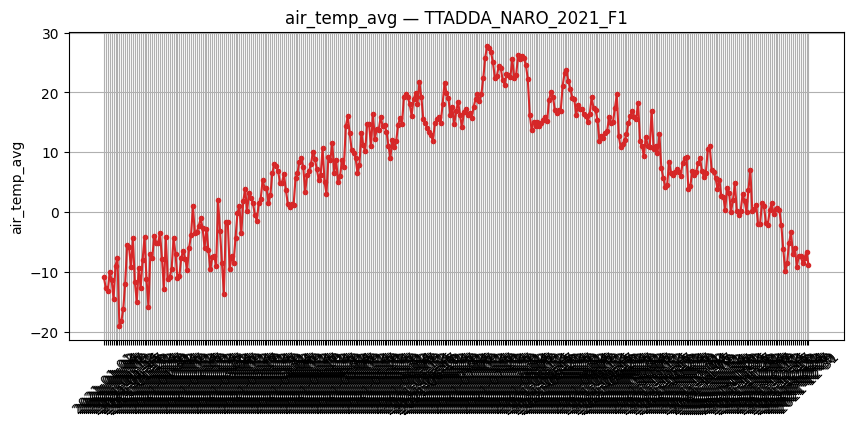

In [ ]:
"""Weather ground truth for the same field: on-site AmeDAS daily records."""
weather_vars = [v for v in vars_study if v in ("air_temp_avg", "percipitation_mm", "rad_MJm2")]
field_w = next((u for u in obs_units["obsUnitId"] if u.endswith("_F1")), obs_units["obsUnitId"].iloc[0])
if weather_vars:
    df_w = obj.get_observed_variables(field_w, weather_vars[0])[0]
    print(df_w.head())
    import matplotlib.pyplot as plt
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(df_w["collectionDate"], df_w[weather_vars[0]], marker=".", color="tab:red")
    ax1.set_ylabel(weather_vars[0]); ax1.tick_params(axis="x", rotation=45)
    ax1.grid(); ax1.set_title(f"{weather_vars[0]} — {field_w}")
    plt.show()
else:
    print("no weather variables in this study")

## 10 · Imagery links: RGB orthomosaics per collection date

The **Observed Variable** sheet maps `rgb_orthomosaic_*` variables to GeoTIFF files; the loader returns `(collectionDate, path)` pairs. We print them for one field — this is the imagery *link inventory* without downloading gigabyte rasters.

**日本語**: オルソモザイクGeoTIFFは巨大なため、ここでは日付とパスの一覧（リンク）を表示するだけにします。

In [ ]:
field = next((u for u in obs_units["obsUnitId"] if u.endswith("_F1")), obs_units["obsUnitId"].iloc[0])
ortho_vars = [v for v in vars_study if "orthomosaic" in v]
print("field:", field, "| ortho variables:", ortho_vars)
if ortho_vars:
    entries = obj.get_observed_variables(field, ortho_vars[0])
    n_shown = 0
    for item in entries:
        if isinstance(item, list) and len(item) == 2:
            date, path = item
            print(f"Date: {date} | File: {path}")
            n_shown += 1
        if n_shown >= 10: break
    print(f"... ({len(entries)} entries total)")

field: TTADDA_NARO_2021_F1 | ortho variables: ['rgb_orthomosaic_camera1', 'dsm_orthomosaic_camera1', 'blue_orthomosaic_camera1', 'green_orthomosaic_camera1', 'red_orthomosaic_camera1', 'nir_orthomosaic_camera1']
Date: 2021-05-18 | File: /content/data/TTADDA_UAV_01/TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-05-18/20210518_rgb.tif
Date: 2021-05-25 | File: /content/data/TTADDA_UAV_01/TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-05-25/20210525_rgb.tif
Date: 2021-06-01 | File: /content/data/TTADDA_UAV_01/TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-06-01/20210601_rgb.tif
Date: 2021-06-07 | File: /content/data/TTADDA_UAV_01/TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-06-07/20210607_rgb.tif
Date: 2021-06-14 | File: /content/data/TTADDA_UAV_01/TTADDA_UAV_01/TTADDA_NARO_2021/TTADDA_NARO_2021_F1/drone_data/2021-06-14/20210614_rgb.tif
Date: 2021-06-22 | File: /content/data/TTADDA_UAV_01/TTADDA_UAV_01/TTADDA

## 11 · (Optional) Visual check of the smallest RGB orthomosaic

Only runs if the pre-selected smallest RGB orthomosaic is small enough and was extracted in section 5. Reading the GeoTIFF uses `rasterio` on the Colab VM.

**日本語**: 事前に選んだ最小のRGBオルソモザイクが小さい場合のみ、ラスタとして読んで表示します（重い場合は自動スキップ）。

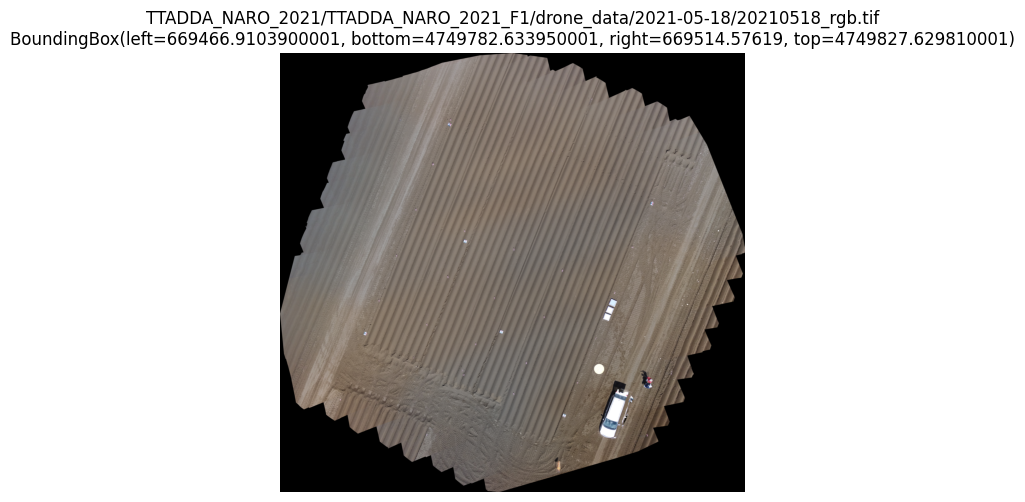

In [ ]:
try:
    import rasterio
    if ortho_pick is not None:
        tif = PROJECT_DIR / ortho_pick.filename
        if tif.exists():
            with rasterio.open(tif) as src:
                img = src.read([1, 2, 3]) if src.count >= 3 else src.read(1)
                b = src.bounds
            import matplotlib.pyplot as plt
            if img.ndim == 3:
                img = img.transpose(1, 2, 0)
                img = (img - img.min()) / max(img.max() - img.min(), 1)
            plt.figure(figsize=(6, 6))
            plt.imshow(img if img.ndim == 2 or img.dtype != 'uint8' else img)
            plt.title(f"{ortho_pick.filename}\n{b}")
            plt.axis("off"); plt.show()
        else:
            print("ortho not extracted (too large); skipped")
    else:
        print("no rgb orthomosaic member found in this zip")
except ImportError:
    print("rasterio unavailable; skipped")

## 12 · Summary and limitations

**Reproduced**: the paper's minimal reproduction — MIAPPE metadata + TTADDA_NARO_2021 study loaded with the authors' own loader; ground-truth CSVs and orthomosaic links inspected. All inputs are pinned: GitHub commit `2fd6e1902e618619a7d236c9007b9e4b9cd6aac7`, 4TU item v1 (published 2025-09-03).

**Limitations** (also listed in the paper's study flow):
- Flight parameters (altitude, overlap, GCPs), cultivar lists and weather-instrument details live in the per-study 4TU records, not the data paper text.
- Most orthomosaics are gigabyte-scale; only one small RGB tile (if any) is displayed.
- The paper itself reports no quantitative validation — downstream comparisons (e.g., UAV vs manual ground coverage) are prospective reuse cases.
- The MIAPPE xlsx `dataFileLink` layout was reconciled by basename; author paths refer to their external drive.

**日本語**: 本ノートブックはデータ論文の最小再現（MIAPPEメタデータ+NARO 2021の地面データ・画像リンク確認）です。飛行条件や品種リスト等の詳細は4TUの各スタディ記録にあり、巨大オルソモザイクは1枚（条件付き）のみ表示します。論文自体は新規解析を行わないデータ論文です。